# StockVision — Model Training

## Objective

Train and evaluate baseline classification models for **1D, 5D, and 20D stock-direction prediction**.

This notebook is intentionally focused on **analysis and visualization**. The reusable ML implementation lives in `src/train_models.py`.

### Models
- Logistic Regression
- Default Random Forest

### Validation strategy
- Chronological 80/20 train-test split
- `TimeSeriesSplit` cross-validation on the training portion only
- The final test set is kept untouched during cross-validation

### Horizons
- 1D: next trading day
- 5D: next 5 trading days
- 20D: next 20 trading days


## 1. Imports

The notebook imports the reusable training function from `src/train_models.py` instead of duplicating model-training logic.

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore')

In [3]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
    

from src.config import STOCKS, FEATURES

from src.train_models import HORIZONS, train_baseline_models

from src.data_loader import load_stock_data

## 2. Configuration

Stocks and features are imported from the central project configuration so that the notebook does not maintain a second copy.

In [4]:
stocks = STOCKS
horizons = HORIZONS
features = FEATURES

print("Stocks:", stocks)
print("Horizons:", horizons)
print("Number of features:", len(features))

Stocks: ['AAPL', 'MSFT', 'NVDA', 'AMZN', 'RELIANCE.NS', 'TCS.NS', 'HDFCBANK.NS', 'INFY.NS']
Horizons: ['1D', '5D', '20D']
Number of features: 18


## 3. Baseline Model Training

The reusable function performs the complete baseline-training workflow for all **8 stocks × 3 horizons**.

It returns the trained models, predictions, train/test datasets, evaluation results, and Time-Series CV results so that this notebook can continue with analysis without duplicating the implementation.

In [6]:
results = train_baseline_models()

logistic_results_df = results["logistic_results"]
default_rf_results_df = results["default_rf_results"]
cv_results_df = results["cv_results"]

logistic_predictions = results["logistic_predictions"]
rf_predictions = results["rf_predictions"]

X_train = results["X_train"]
X_test = results["X_test"]
y_train = results["y_train"]
y_test = results["y_test"]

logistic_models = results.get("logistic_models")
rf_models = results.get("rf_models")

print("\nBaseline training completed successfully.")

Training AAPL - 1D...
AAPL - 1D completed successfully.
Training MSFT - 1D...
MSFT - 1D completed successfully.
Training NVDA - 1D...
NVDA - 1D completed successfully.
Training AMZN - 1D...
AMZN - 1D completed successfully.
Training RELIANCE.NS - 1D...
RELIANCE.NS - 1D completed successfully.
Training TCS.NS - 1D...
TCS.NS - 1D completed successfully.
Training HDFCBANK.NS - 1D...
HDFCBANK.NS - 1D completed successfully.
Training INFY.NS - 1D...
INFY.NS - 1D completed successfully.
Training AAPL - 5D...
AAPL - 5D completed successfully.
Training MSFT - 5D...
MSFT - 5D completed successfully.
Training NVDA - 5D...
NVDA - 5D completed successfully.
Training AMZN - 5D...
AMZN - 5D completed successfully.
Training RELIANCE.NS - 5D...
RELIANCE.NS - 5D completed successfully.
Training TCS.NS - 5D...
TCS.NS - 5D completed successfully.
Training HDFCBANK.NS - 5D...
HDFCBANK.NS - 5D completed successfully.
Training INFY.NS - 5D...
INFY.NS - 5D completed successfully.
Training AAPL - 20D...
AAPL 

## 4. Returned Data Verification

Confirm that the reusable training pipeline produced results for every stock and horizon.

In [7]:
expected_rows = len(stocks) * len(horizons)

print("Expected stock-horizon combinations:", expected_rows)
print("Logistic result rows:", len(logistic_results_df))
print("Random Forest result rows:", len(default_rf_results_df))
print("CV result rows:", len(cv_results_df))

display(logistic_results_df.head())
display(default_rf_results_df.head())
display(cv_results_df.head())

Expected stock-horizon combinations: 24
Logistic result rows: 24
Random Forest result rows: 24
CV result rows: 24


,Horizon,Stock,Accuracy,Precision,Recall,F1-Score
0,1D,AAPL,0.487047,0.540351,0.481250,0.509091
1,1D,AMZN,0.509499,0.541176,0.308725,0.393162
2,1D,HDFCBANK.NS,0.467487,0.469854,0.824818,0.598675
3,1D,INFY.NS,0.520211,0.503448,0.530909,0.516814
4,1D,MSFT,0.487047,0.510000,0.668852,0.578723


,Horizon,Stock,Accuracy,Precision,Recall,F1-Score
0,1D,AAPL,0.457686,0.687500,0.034375,0.065476
1,1D,AMZN,0.519862,0.592593,0.214765,0.315271
2,1D,HDFCBANK.NS,0.490334,0.414894,0.142336,0.211957
3,1D,INFY.NS,0.511424,0.493088,0.389091,0.434959
4,1D,MSFT,0.488774,0.520548,0.373770,0.435115


,Horizon,Stock,Logistic Regression CV,Default Random Forest CV,Logistic Regression CV Std,Default Random Forest CV Std
0,1D,AAPL,0.487047,0.473575,0.018172,0.014415
1,1D,AMZN,0.520725,0.483420,0.037863,0.022857
2,1D,HDFCBANK.NS,0.499471,0.504233,0.021905,0.016948
3,1D,INFY.NS,0.501058,0.483069,0.029771,0.015749
4,1D,MSFT,0.516580,0.489119,0.031329,0.029962


## 5. Chronological Split Verification

The model-training module uses a chronological split. The training portion must occur before the test portion in time.

In [9]:
for horizon in horizons:
    for stock in stocks:
        train_dates = pd.Series(X_train[horizon][stock].index)
        test_dates = pd.Series(X_test[horizon][stock].index)

        print(
            f"{stock} - {horizon}: "
            f"train={len(train_dates)}, test={len(test_dates)}"
        )
    print()

AAPL - 1D: train=2316, test=579
MSFT - 1D: train=2316, test=579
NVDA - 1D: train=2316, test=579
AMZN - 1D: train=2316, test=579
RELIANCE.NS - 1D: train=2272, test=569
TCS.NS - 1D: train=2272, test=569
HDFCBANK.NS - 1D: train=2272, test=569
INFY.NS - 1D: train=2272, test=569

AAPL - 5D: train=2312, test=579
MSFT - 5D: train=2312, test=579
NVDA - 5D: train=2312, test=579
AMZN - 5D: train=2312, test=579
RELIANCE.NS - 5D: train=2270, test=568
TCS.NS - 5D: train=2270, test=568
HDFCBANK.NS - 5D: train=2270, test=568
INFY.NS - 5D: train=2270, test=568

AAPL - 20D: train=2300, test=576
MSFT - 20D: train=2300, test=576
NVDA - 20D: train=2300, test=576
AMZN - 20D: train=2300, test=576
RELIANCE.NS - 20D: train=2258, test=565
TCS.NS - 20D: train=2258, test=565
HDFCBANK.NS - 20D: train=2258, test=565
INFY.NS - 20D: train=2258, test=565



## 6. Logistic Regression — Evaluation

Display test-set performance for Logistic Regression across all horizons.

In [10]:
logistic_results_df

,Horizon,Stock,Accuracy,Precision,Recall,F1-Score
0,1D,AAPL,0.487047,0.540351,0.481250,0.509091
1,1D,AMZN,0.509499,0.541176,0.308725,0.393162
2,1D,HDFCBANK.NS,0.467487,0.469854,0.824818,0.598675
3,1D,INFY.NS,0.520211,0.503448,0.530909,0.516814
4,1D,MSFT,0.487047,0.510000,0.668852,0.578723
5,1D,NVDA,0.523316,0.525735,0.940789,0.674528
6,1D,RELIANCE.NS,0.476274,0.481395,0.734043,0.581461
7,1D,TCS.NS,0.481547,0.438650,0.560784,0.492255
8,20D,AAPL,0.534722,0.665552,0.542234,0.597598
9,20D,AMZN,0.532986,0.671875,0.385075,0.489564


## 7. Logistic Regression — Prediction Distribution

Check how many DOWN and UP predictions are produced by each model.

In [11]:
for horizon in horizons:
    print(f"\n===== {horizon} =====")

    for stock in stocks:
        predictions = logistic_predictions[horizon][stock]
        counts = pd.Series(predictions).value_counts().sort_index()

        print(
            f"{stock}: "
            f"DOWN={counts.get(0, 0)}, "
            f"UP={counts.get(1, 0)}"
        )


===== 1D =====
AAPL: DOWN=294, UP=285
MSFT: DOWN=179, UP=400
NVDA: DOWN=35, UP=544
AMZN: DOWN=409, UP=170
RELIANCE.NS: DOWN=139, UP=430
TCS.NS: DOWN=243, UP=326
HDFCBANK.NS: DOWN=88, UP=481
INFY.NS: DOWN=279, UP=290

===== 5D =====
AAPL: DOWN=209, UP=370
MSFT: DOWN=75, UP=504
NVDA: DOWN=229, UP=350
AMZN: DOWN=507, UP=72
RELIANCE.NS: DOWN=115, UP=453
TCS.NS: DOWN=85, UP=483
HDFCBANK.NS: DOWN=143, UP=425
INFY.NS: DOWN=4, UP=564

===== 20D =====
AAPL: DOWN=277, UP=299
MSFT: DOWN=217, UP=359
NVDA: DOWN=408, UP=168
AMZN: DOWN=384, UP=192
RELIANCE.NS: DOWN=283, UP=282
TCS.NS: DOWN=54, UP=511
HDFCBANK.NS: DOWN=455, UP=110
INFY.NS: DOWN=3, UP=562


## 8. Actual Target Distribution

Compare the model prediction distribution with the actual test-set target distribution.

In [12]:
for horizon in horizons:
    print(f"\n===== {horizon} =====")

    for stock in stocks:
        actual = y_test[horizon][stock]
        counts = pd.Series(actual).value_counts().sort_index()

        print(
            f"{stock}: "
            f"DOWN={counts.get(0, 0)}, "
            f"UP={counts.get(1, 0)}"
        )


===== 1D =====
AAPL: DOWN=259, UP=320
MSFT: DOWN=274, UP=305
NVDA: DOWN=275, UP=304
AMZN: DOWN=281, UP=298
RELIANCE.NS: DOWN=287, UP=282
TCS.NS: DOWN=314, UP=255
HDFCBANK.NS: DOWN=295, UP=274
INFY.NS: DOWN=294, UP=275

===== 5D =====
AAPL: DOWN=252, UP=327
MSFT: DOWN=267, UP=312
NVDA: DOWN=252, UP=327
AMZN: DOWN=273, UP=306
RELIANCE.NS: DOWN=282, UP=286
TCS.NS: DOWN=329, UP=239
HDFCBANK.NS: DOWN=281, UP=287
INFY.NS: DOWN=275, UP=293

===== 20D =====
AAPL: DOWN=209, UP=367
MSFT: DOWN=291, UP=285
NVDA: DOWN=227, UP=349
AMZN: DOWN=241, UP=335
RELIANCE.NS: DOWN=308, UP=257
TCS.NS: DOWN=334, UP=231
HDFCBANK.NS: DOWN=267, UP=298
INFY.NS: DOWN=280, UP=285


## 9. Logistic Regression — Confusion Matrices

Confusion matrices show the number of correct and incorrect DOWN/UP classifications.

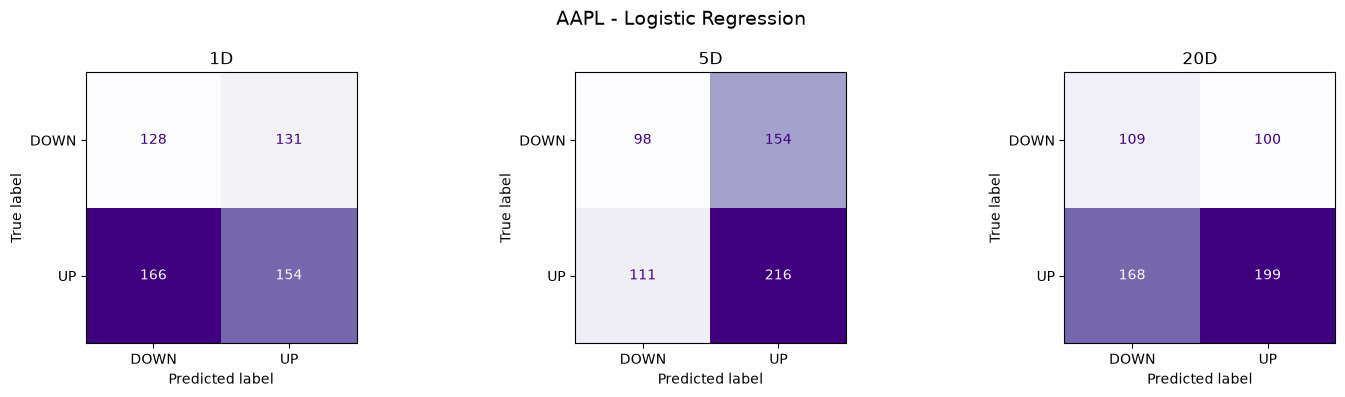

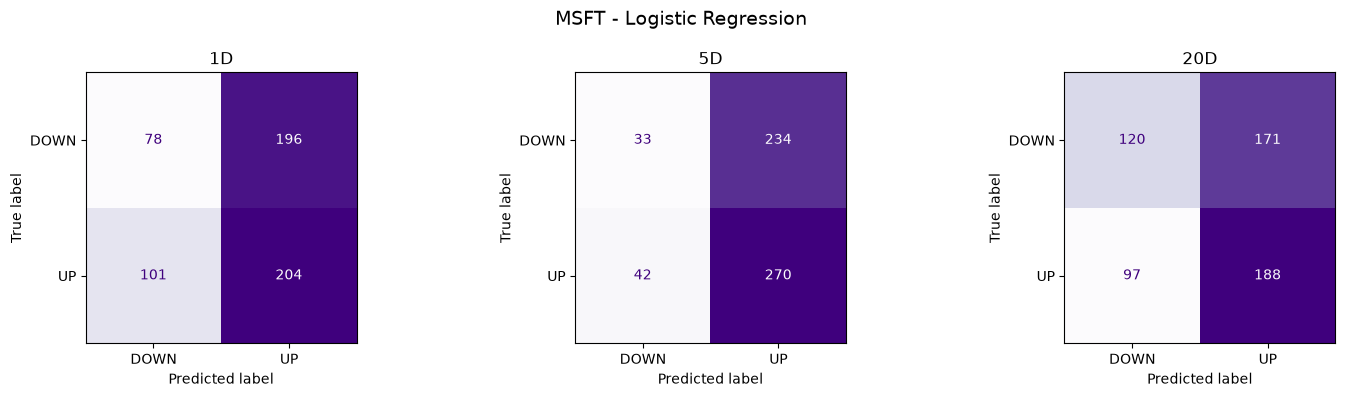

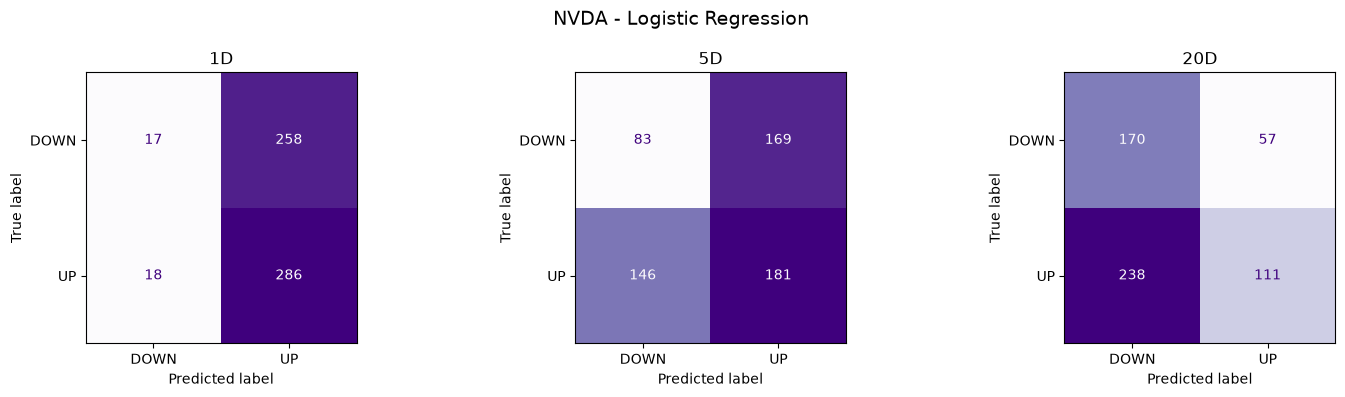

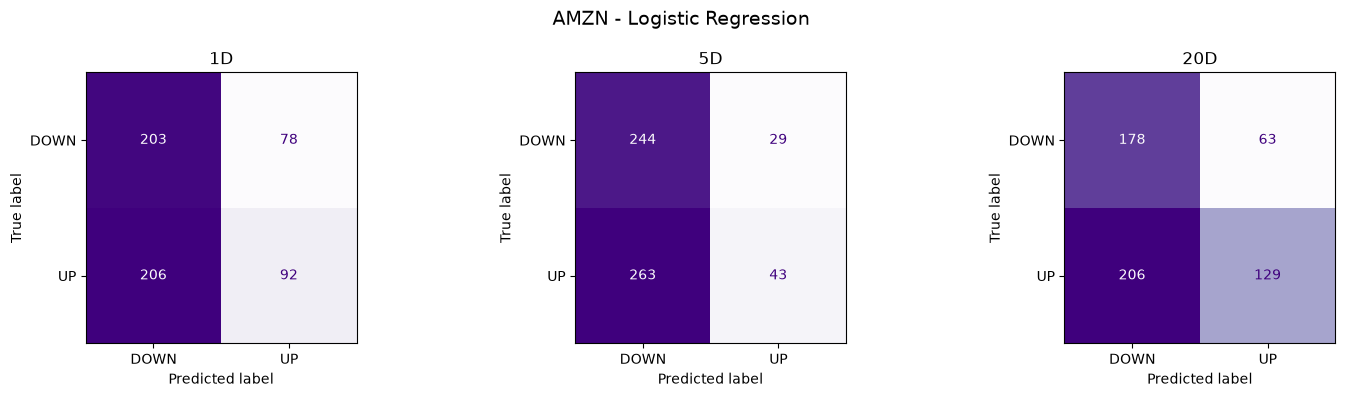

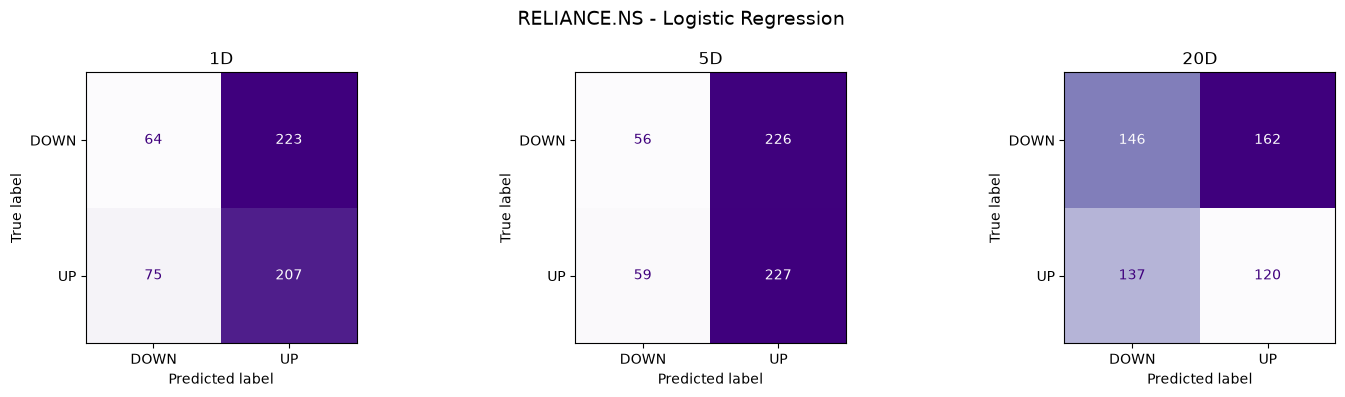

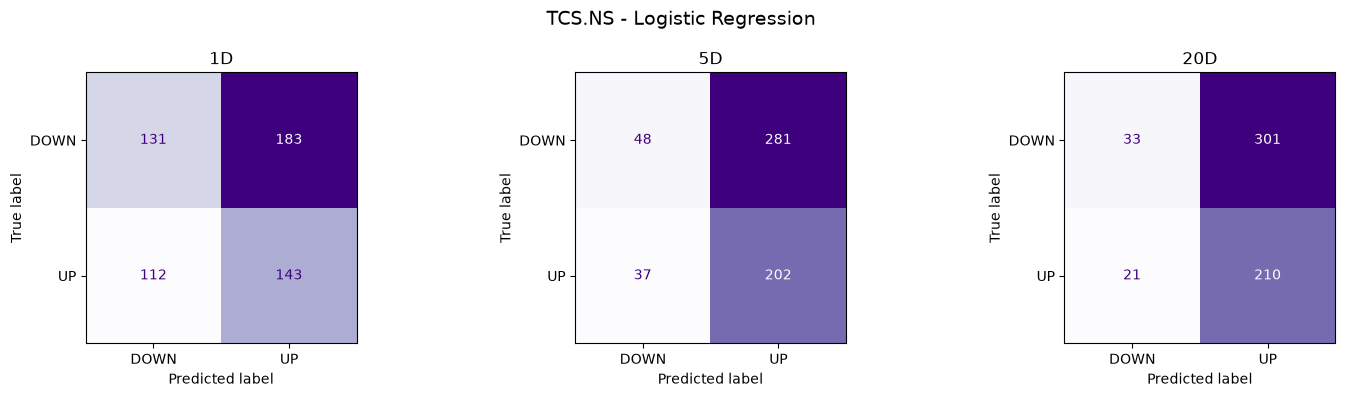

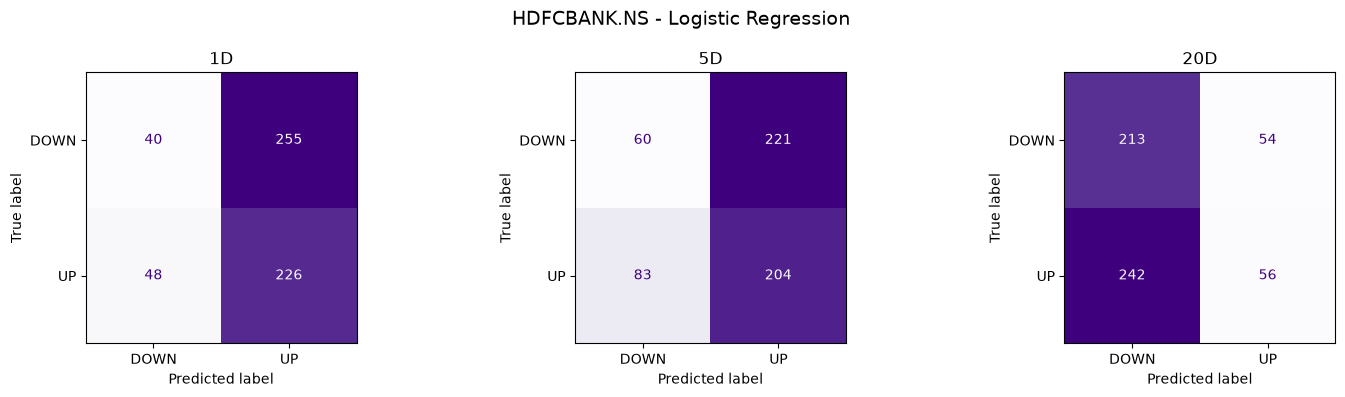

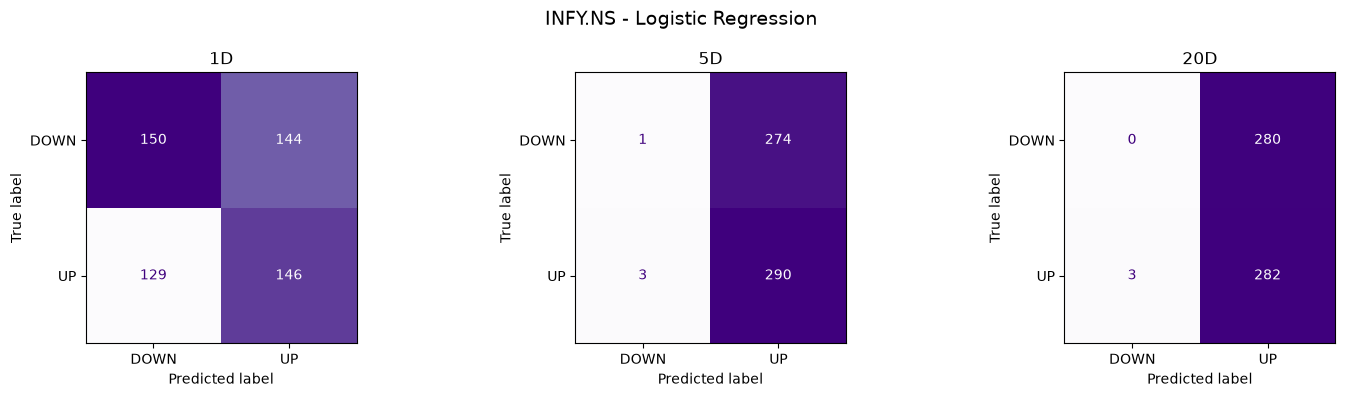

In [ ]:
horizons = ["1D", "5D", "20D"]

for stock in stocks:

    fig, axes = plt.subplots(
        1, 3,
        figsize=(15, 4)
    )

    for i, horizon in enumerate(horizons):

        y_true = y_test[horizon][stock]
        y_pred = logistic_predictions[horizon][stock]

        cm = confusion_matrix(
            y_true,
            y_pred
        )

        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=["DOWN", "UP"]
        )

        disp.plot(
            ax=axes[i],
            cmap="Purples",
            colorbar=False
        )

        axes[i].set_title(
            f"{horizon}"
        )

    fig.suptitle(
        f"{stock} - Logistic Regression",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()

## 10. Default Random Forest — Evaluation

Display test-set performance for the default Random Forest models.

In [14]:
default_rf_results_df

,Horizon,Stock,Accuracy,Precision,Recall,F1-Score
0,1D,AAPL,0.457686,0.687500,0.034375,0.065476
1,1D,AMZN,0.519862,0.592593,0.214765,0.315271
2,1D,HDFCBANK.NS,0.490334,0.414894,0.142336,0.211957
3,1D,INFY.NS,0.511424,0.493088,0.389091,0.434959
4,1D,MSFT,0.488774,0.520548,0.373770,0.435115
5,1D,NVDA,0.531952,0.539568,0.740132,0.624133
6,1D,RELIANCE.NS,0.560633,0.572072,0.450355,0.503968
7,1D,TCS.NS,0.488576,0.439597,0.513725,0.473779
8,20D,AAPL,0.413194,0.754386,0.117166,0.202830
9,20D,AMZN,0.548611,0.570621,0.904478,0.699769


## 11. Default Random Forest — Prediction Distribution

In [15]:
for horizon in horizons:
    print(f"\n===== {horizon} =====")

    for stock in stocks:
        predictions = rf_predictions[horizon][stock]
        counts = pd.Series(predictions).value_counts().sort_index()

        print(
            f"{stock}: "
            f"DOWN={counts.get(0, 0)}, "
            f"UP={counts.get(1, 0)}"
        )


===== 1D =====
AAPL: DOWN=563, UP=16
MSFT: DOWN=360, UP=219
NVDA: DOWN=162, UP=417
AMZN: DOWN=471, UP=108
RELIANCE.NS: DOWN=347, UP=222
TCS.NS: DOWN=271, UP=298
HDFCBANK.NS: DOWN=475, UP=94
INFY.NS: DOWN=352, UP=217

===== 5D =====
AAPL: DOWN=569, UP=10
MSFT: DOWN=448, UP=131
NVDA: DOWN=117, UP=462
AMZN: DOWN=542, UP=37
RELIANCE.NS: DOWN=236, UP=332
TCS.NS: DOWN=226, UP=342
HDFCBANK.NS: DOWN=494, UP=74
INFY.NS: DOWN=367, UP=201

===== 20D =====
AAPL: DOWN=519, UP=57
MSFT: DOWN=429, UP=147
NVDA: DOWN=571, UP=5
AMZN: DOWN=45, UP=531
RELIANCE.NS: DOWN=241, UP=324
TCS.NS: DOWN=238, UP=327
HDFCBANK.NS: DOWN=545, UP=20
INFY.NS: DOWN=346, UP=219


## 12. Default Random Forest — Confusion Matrices

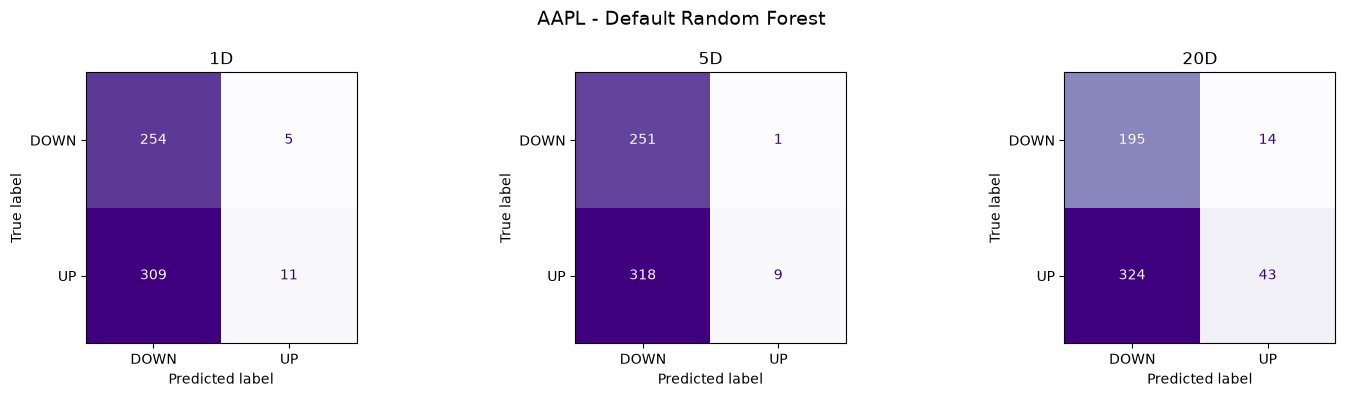

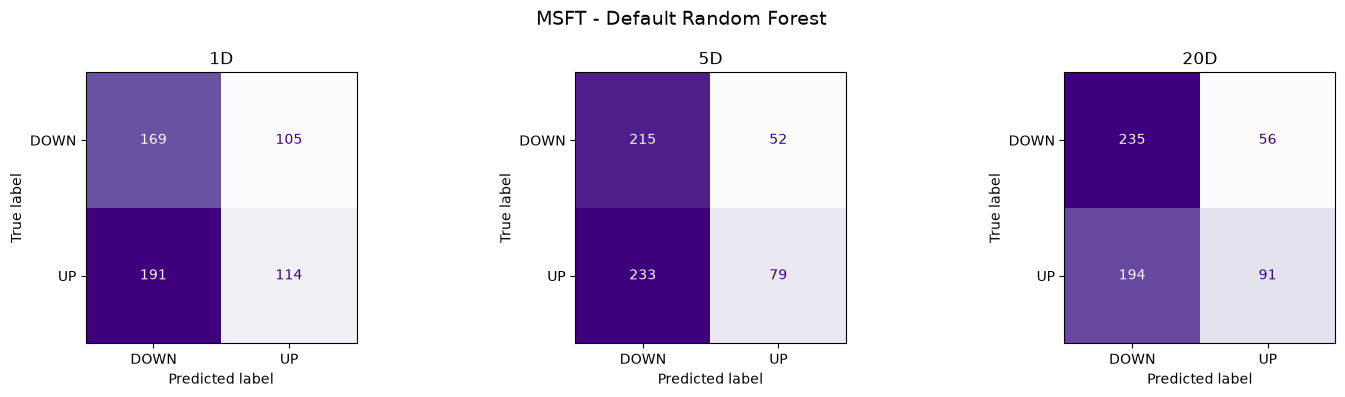

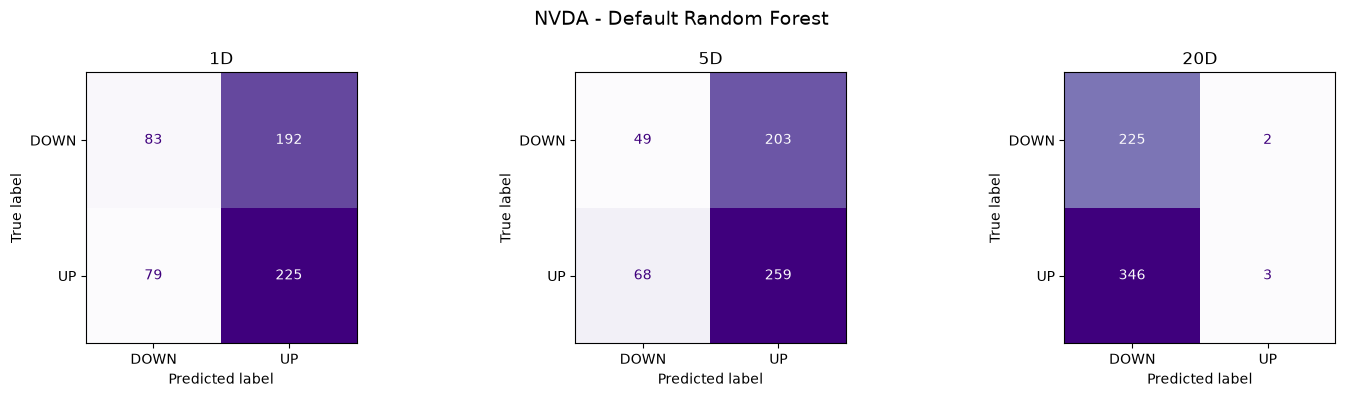

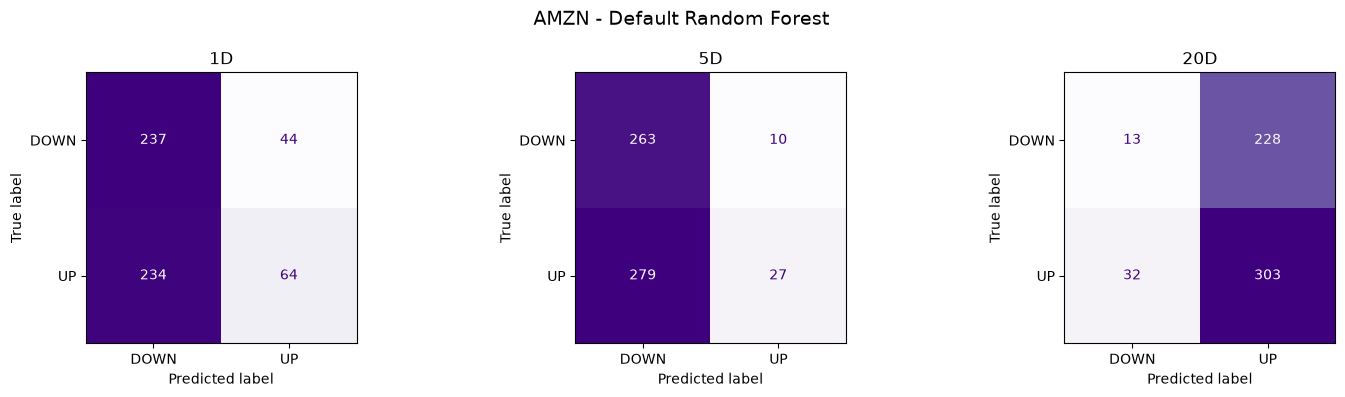

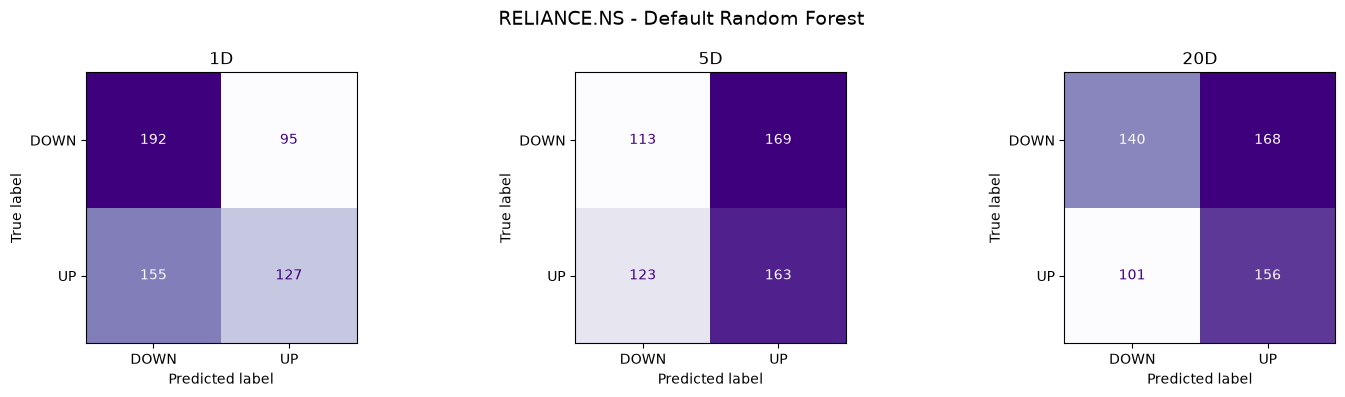

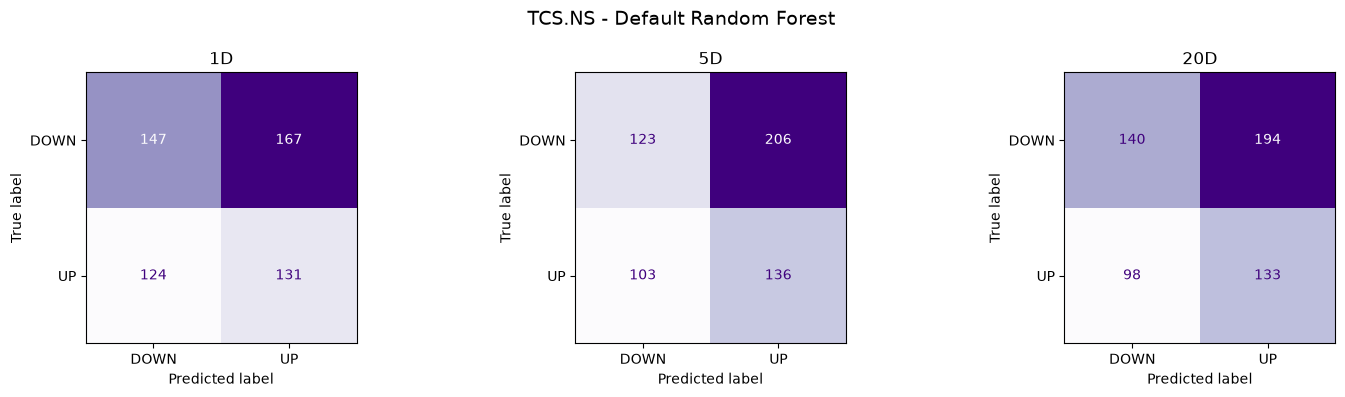

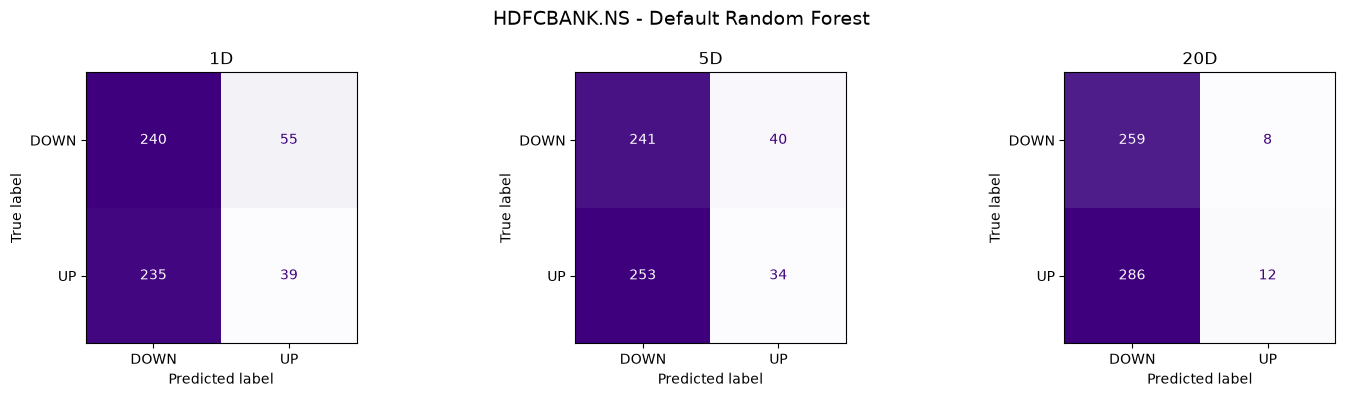

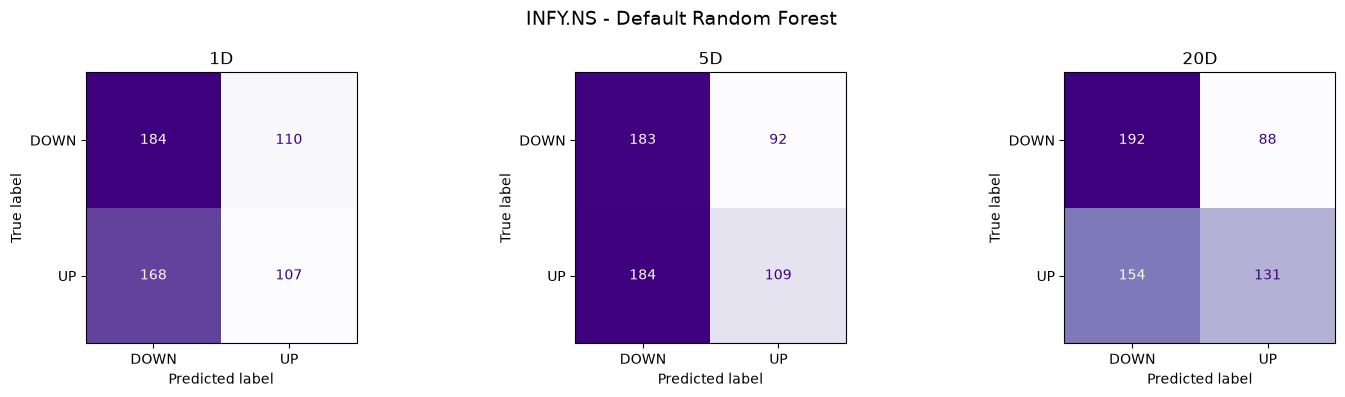

In [ ]:
horizons = ["1D", "5D", "20D"]

for stock in stocks:

    fig, axes = plt.subplots(
        1, 3,
        figsize=(15, 4)
    )

    for i, horizon in enumerate(horizons):

        y_true = y_test[horizon][stock]
        y_pred = rf_predictions[horizon][stock]

        cm = confusion_matrix(
            y_true,
            y_pred
        )

        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=["DOWN", "UP"]
        )

        disp.plot(
            ax=axes[i],
            cmap="Purples",
            colorbar=False
        )

        axes[i].set_title(
            f"{horizon}"
        )

    fig.suptitle(
        f"{stock} - Default Random Forest",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()

## 13. Time-Series Cross-Validation Results

Time-Series CV is performed inside the reusable training module on the training portion only. The results below are used for model comparison.

In [ ]:
cv_results_df

## 14. Baseline Model Comparison

Combine Logistic Regression and Default Random Forest test-set results with their Time-Series CV results.

In [ ]:
comparison_df = (
    logistic_results_df[["Horizon", "Stock", "Accuracy"]]
    .rename(columns={"Accuracy": "Logistic Regression"})
    .merge(
        default_rf_results_df[["Horizon", "Stock", "Accuracy"]]
        .rename(columns={"Accuracy": "Default Random Forest"}),
        on=["Horizon", "Stock"],
        how="inner"
    )
    .merge(
        cv_results_df,
        on=["Horizon", "Stock"],
        how="left"
    )
)

comparison_df

## 15. Baseline Model Comparison by Horizon

In [ ]:
for horizon in horizons:
    print(f"\n===== {horizon} =====")
    display(
        comparison_df[comparison_df["Horizon"] == horizon]
        .sort_values("Stock")
    )

## 16. Baseline Model Training Summary

Notebook 07 ends after baseline training and analysis. Hyperparameter tuning is intentionally handled separately in **Notebook 08** using `src/tune_models.py`.

In [ ]:
print("StockVision baseline training completed.")
print(f"Stocks: {len(stocks)}")
print(f"Horizons: {len(horizons)}")
print(f"Stock-horizon models: {len(stocks) * len(horizons)}")
print("Models: Logistic Regression + Default Random Forest")
print("Next step: Notebook 08 — Hyperparameter Tuning")